In [2]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations, especially with arrays

import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations

from sklearn.linear_model import LinearRegression # For implementing linear regression model
from sklearn.preprocessing import PolynomialFeatures # For generating polynomial features from existing features

from sklearn.metrics import (
    mean_absolute_error, # Metric for evaluating regression models (MAE)
    mean_squared_error, # Metric for evaluating regression models (MSE)
    r2_score # Metric for evaluating regression models (R-squared)
)

import warnings # To manage warnings generated by Python
warnings.filterwarnings("ignore") # Ignore all warnings to keep output clean

**Load Dataset**

In [3]:
df = pd.read_csv("Position_Salaries.csv") # Load the dataset from a CSV file into a pandas DataFrame

In [4]:
df # Display the entire DataFrame to see its contents

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


**View Dataset**

In [5]:
df.head() # Display the first 5 rows of the DataFrame to get a quick overview

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


**Dataset Information**

In [6]:
df.info() # Print a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


**Statistical Summary**

In [7]:
df.describe() # Generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


**Select Features and Target**

In [24]:
X = df[["Level"]]
X # Select the 'Level' column as the feature (independent variable) for the model

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [25]:
y = df["Salary"]
y# Select the 'Salary' column as the target (dependent variable) for the model

,Salary
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


**Visualize Data**

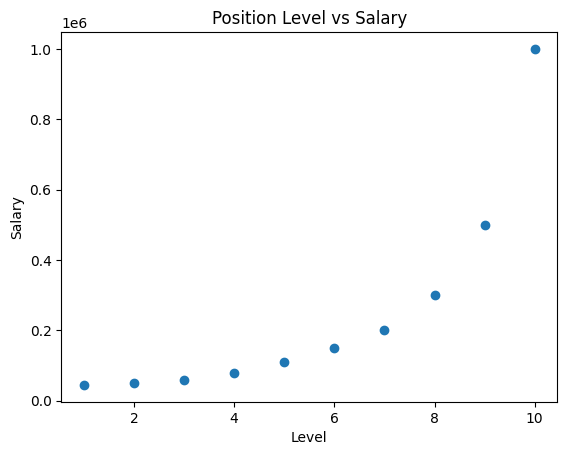

In [10]:
plt.scatter(
    X, # Plot the 'Level' as x-coordinates
    y # Plot the 'Salary' as y-coordinates
)

plt.xlabel("Level") # Set the label for the x-axis
plt.ylabel("Salary") # Set the label for the y-axis

plt.title("Position Level vs Salary") # Set the title of the scatter plot

plt.show() # Display the plot

**Create Linear Regression Model**

In [11]:
linear_model = LinearRegression() # Instantiate a Linear Regression model object

linear_model.fit(
    X, # Fit the model using the 'Level' data as features
    y # Fit the model using the 'Salary' data as the target
) # Train the linear regression model

LinearRegression()

**Prediction using Linear Regression**

In [12]:
y_linear_pred = linear_model.predict(X) # Make predictions on the training data using the linear regression model

**Plot Linear Regression**

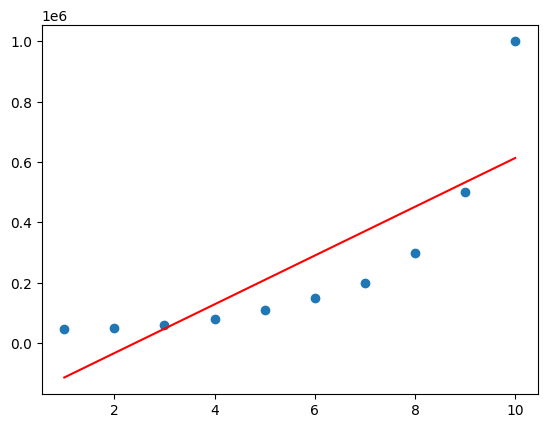

In [13]:
plt.scatter(
    X, # Plot the original 'Level' as x-coordinates
    y # Plot the original 'Salary' as y-coordinates
)

plt.plot(
    X, # Plot 'Level' as x-coordinates for the regression line
    y_linear_pred, # Plot the predicted 'Salary' values as y-coordinates for the regression line
    color="red" # Set the color of the regression line to red
)

plt.show() # Display the plot

**Create Polynomial Features**

In [14]:
poly = PolynomialFeatures(
    degree=4 # Specify the degree of the polynomial features to be generated (e.g., up to x^4)
)

X_poly = poly.fit_transform(X) # Transform the original features 'X' into polynomial features

**Train Polynomial Regression Model**

In [15]:
poly_model = LinearRegression() # Instantiate a new Linear Regression model to use with polynomial features

poly_model.fit(
    X_poly, # Fit the model using the polynomial features (X_poly)
    y # Fit the model using the original 'Salary' data as the target
) # Train the polynomial regression model

LinearRegression()

**Predict Salary**

In [16]:
y_poly_pred = poly_model.predict(
    X_poly # Make predictions using the trained polynomial model and the polynomial features (X_poly)
) # Get predicted salaries from the polynomial regression model

**Visualize Polynomial Curve**

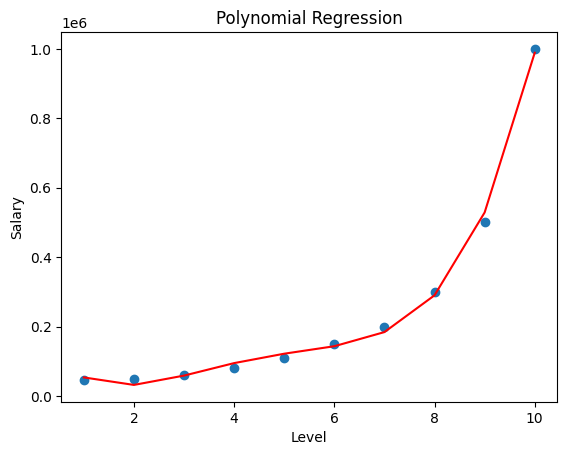

In [17]:
plt.scatter(
    X, # Plot the original 'Level' as x-coordinates (scatter plot of actual data)
    y # Plot the original 'Salary' as y-coordinates (scatter plot of actual data)
)

plt.plot(
    X, # Plot 'Level' as x-coordinates for the polynomial regression curve
    y_poly_pred, # Plot the predicted 'Salary' values from the polynomial model as y-coordinates
    color="red" # Set the color of the polynomial regression curve to red
)

plt.xlabel("Level") # Set the label for the x-axis

plt.ylabel("Salary") # Set the label for the y-axis

plt.title(
    "Polynomial Regression" # Set the title of the plot
)

plt.show() # Display the plot

**Predict New Salary**

In [18]:
new_level = [[6.5]] # Define a new level (e.g., 6.5) for which to predict the salary

new_level_poly = poly.transform(
    new_level # Transform the new level into polynomial features using the previously fitted PolynomialFeatures object
)

prediction = poly_model.predict(
    new_level_poly # Predict the salary for the new polynomial level using the trained polynomial model
)

print(prediction) # Print the predicted salary for the new level

[158862.45265155]


**Model Evaluation**

**MAE**

In [19]:
mae = mean_absolute_error(
    y, # The true target values (actual salaries)
    y_poly_pred # The predicted target values (predicted salaries from polynomial model)
)

print(mae) # Print the Mean Absolute Error

12681.818181828514


**MSE**

In [20]:
mse = mean_squared_error(
    y, # The true target values (actual salaries)
    y_poly_pred # The predicted target values (predicted salaries from polynomial model)
)

print(mse) # Print the Mean Squared Error

210343822.84381685


**RMSE**

In [21]:
rmse = np.sqrt(mse) # Calculate the Root Mean Squared Error by taking the square root of the MSE

print(rmse) # Print the Root Mean Squared Error

14503.234909626777


**R² Score**

In [22]:
r2 = r2_score(
    y, # The true target values (actual salaries)
    y_poly_pred # The predicted target values (predicted salaries from polynomial model)
)

print(r2) # Print the R-squared score

0.9973922891706614


**Compare Linear vs Polynomial Regression**

In [23]:
comparison = pd.DataFrame({ # Create a pandas DataFrame to compare the models

"Model": # Column for model names
[
"Linear Regression", # Name for the linear regression model
"Polynomial Regression" # Name for the polynomial regression model
],

"R2 Score": # Column for R-squared scores
[
r2_score(y,y_linear_pred), # Calculate R-squared for the linear regression model
r2_score(y,y_poly_pred) # Calculate R-squared for the polynomial regression model
]

})

comparison # Display the comparison DataFrame

,Model,R2 Score
0,Linear Regression,0.669041
1,Polynomial Regression,0.997392
